## 2. Dataset Choice

### Why this dataset

`international_matches1.csv` is well suited to an exploratory data analysis assignment for three concrete reasons:

**Historical depth.** The log spans 1872 to 2022 -- 150 years of recorded international football, from the first-ever official international fixture (Scotland vs. England) through the modern professional era. Few tabular datasets available at this scale offer a genuine, orderable century-and-a-half time series rather than a snapshot; this depth is what makes the era-by-era stability checks in this notebook possible at all (see the Index Analysis section), and it surfaces real non-stationarity -- scoring patterns, skewness, and even outlier rates all shift measurably across the timeline rather than staying fixed.

**A rich mix of variable types.** The raw table alone already exceeds the assignment's minimum requirements (1,000+ rows, 10+ columns, a mix of numeric/temporal/categorical fields) with 17,769 rows; after the Section 3 merge with `world_cups1.csv` it grows to 17 columns. More importantly, the mix is genuinely varied rather than padded: `Home Goals`/`Away Goals` are bounded, right-skewed count variables well suited to comparing multiple outlier-detection methods; `Date`/`Year` provide a real temporal axis; `Tournament` (90 distinct values) and `Home Team`/`Away Team` (214/218 distinct values) are categorical variables spanning very different cardinality regimes, from a handful of dominant categories to a long tail of near-singleton ones. That range is what makes frequency analysis, binning, and category-coverage questions substantive rather than trivial.

**Interesting, real-world biases.** Unlike a synthetic or heavily pre-cleaned dataset, this one carries the kind of structural bias an analyst has to actually reason about: a measurable but statistically modest home-advantage effect (Section 6.2), a participation bias toward historically wealthy, well-established football federations (Section 5.2), and fragmentation across now-defunct national entities like West Germany and Yugoslavia (Section 4.4). The dataset also rewards close reading of its own construction -- merging it with the World Cup summary table exposes a silent reference-table gap (the missing 2022 tournament, Section 4.1) that only surfaces through domain knowledge, not through a mechanical `NaN` count. These are exactly the kind of hidden assumptions and limitations this assignment asks students to uncover, rather than issues that could be resolved by a single `dropna()` call.

Basic domain familiarity with football (tournament structures, the concept of home-venue advantage, the historical churn of national teams) made it possible to sanity-check unusual values against real events -- for example, recognizing the 22-0 and 31-0 scorelines in Section 4.3 as a genuine, well-documented 2001 Oceania qualifying result rather than a data error, which a purely statistical outlier rule could not have distinguished on its own.

## Data Source and Purpose

This analysis combines two tables from the **"FIFA World Cup All Dataset"** collection published on Kaggle by abhijitdahatonde (downloaded above via `kagglehub`):

- **`international_matches1.csv`** — A match-level log of official international football fixtures dating back to 1872. Each row records the tournament type, date, home and away teams, the final score, and whether the match was played at the home team's stadium. This table was assembled to preserve the historical results of national-team football, likely compiled from federation and historical match archives rather than collected for a single research study.
- **`world_cups1.csv`** — A tournament-level summary of every FIFA World Cup held since 1930, listing the host country, the top four finishers, total goals scored, matches played, and the number of qualified teams.

**Purpose of this notebook:** to enrich the match-level dataset with tournament-level context from the World Cups table, producing a single combined dataframe suitable for exploring historical trends in international football ahead of the 2026 World Cup. The two tables are merged on `Year`, which means every match played during a calendar year in which a World Cup took place (not only the World Cup matches themselves) is annotated with that tournament's summary statistics — a modeling choice worth keeping in mind during later analysis, since it links unrelated friendly matches to World Cup outcomes purely by year.

## 3. Meta-Analysis of the Data

### 3.1 File-Level Metadata

In [1]:
import os
import datetime

def report_file_metadata(file_path):
    """Print file size, format, and last-modified timestamp for a raw data file."""
    file_size_bytes = os.path.getsize(file_path)
    last_modified = datetime.datetime.fromtimestamp(os.path.getmtime(file_path))
    print(f"{file_path}")
    print(f"  Size: {file_size_bytes:,} bytes ({file_size_bytes / 1024:.1f} KB)")
    print(f"  Format: CSV (comma-separated values)")
    print(f"  Last modified (local filesystem): {last_modified}")


for raw_file_path in ["archive/international_matches1.csv", "archive/world_cups1.csv"]:
    report_file_metadata(raw_file_path)
    print()

archive/international_matches1.csv
  Size: 1,026,442 bytes (1002.4 KB)
  Format: CSV (comma-separated values)
  Last modified (local filesystem): 2026-07-22 18:35:59.754757

archive/world_cups1.csv
  Size: 1,299 bytes (1.3 KB)
  Format: CSV (comma-separated values)
  Last modified (local filesystem): 2026-07-22 18:35:59.788753



`international_matches1.csv` is roughly 1.0 MB (17,769 data rows), and `world_cups1.csv` is 1.3 KB (21 data rows) -- both plain-text CSV, no proprietary or binary format.

**No genuine creation date is available.** The filesystem "last modified" timestamp only reflects when these files were downloaded/extracted onto this machine, not when the underlying data was originally compiled or published on Kaggle. This is itself a small but real insight: without consulting the Kaggle listing directly, a downstream user has no reliable way to know how current the `world_cups1.csv` reference table actually is -- which is exactly the kind of blind spot that allowed the silent 2018 cutoff (missing the 2022 tournament) to go unnoticed until it was cross-checked against known football history in Section 4.1.

**Purpose recap:** as established in the Data Source and Purpose section above, `international_matches1.csv` is a match-level historical archive and `world_cups1.csv` is a tournament-level summary table used here to enrich it.

### 3.2 Data Structure

In [2]:
import pandas as pd

INTERNATIONAL_MATCHES_PATH = "archive/international_matches1.csv"
WORLD_CUPS_PATH = "archive/world_cups1.csv"

international_matches = pd.read_csv(INTERNATIONAL_MATCHES_PATH)
world_cups = pd.read_csv(WORLD_CUPS_PATH)

In [3]:
# Extract the match year from the Date column so matches can be joined
# with the World Cups table, which is indexed by tournament year.
international_matches["Year"] = pd.to_datetime(international_matches["Date"]).dt.year

In [4]:
# Left join keeps every match while attaching World Cup summary statistics
# for matches whose Year overlaps with a tournament year.
international_matches_enriched = pd.merge(
    international_matches,
    world_cups,
    on="Year",
    how="left"
)

In [5]:
def summarize_dataframe_structure(target_dataframe, dataframe_label):
    """Print the shape, column names, and data types of a dataframe."""
    print(f"--- Structure summary: {dataframe_label} ---")
    print(f"Shape (rows, columns): {target_dataframe.shape}")
    print(f"Column names: {list(target_dataframe.columns)}")
    print("Data types:")
    print(target_dataframe.dtypes)


summarize_dataframe_structure(
    international_matches_enriched,
    "International Matches Enriched with World Cup Data"
)

--- Structure summary: International Matches Enriched with World Cup Data ---
Shape (rows, columns): (17769, 17)
Column names: ['ID', 'Tournament', 'Date', 'Home Team', 'Away Team', 'Home Goals', 'Away Goals', 'Home Stadium or Not', 'Year', 'Host Country', 'Winner', 'Runners-Up', 'Third', 'Fourth', 'Goals Scored', 'Matches Played', 'Qualified Teams']
Data types:
ID                       int64
Tournament                 str
Date                       str
Home Team                  str
Away Team                  str
Home Goals               int64
Away Goals               int64
Home Stadium or Not      int64
Year                     int32
Host Country               str
Winner                     str
Runners-Up                 str
Third                      str
Fourth                     str
Goals Scored           float64
Matches Played         float64
Qualified Teams        float64
dtype: object


**Do the column names make sense?** Yes, and they are self-explanatory without a data dictionary: `Home Team`/`Away Team`/`Home Goals`/`Away Goals` follow an obvious home-vs-away convention, and `Home Stadium or Not` is an unusually explicit (if awkwardly phrased) name for a binary venue flag -- clearer than a terser alternative like `Neutral` would have been, though its polarity (1 = home venue, 0 = neutral) has to be checked rather than assumed from the name alone.

**What do the data types tell us?** The goal columns are `int64` (true counts, confirming Section 4.3's finding of no negative or fractional scores), while every categorical field -- `Tournament`, `Home Team`, `Away Team`, `Date` -- loads as generic `str`/`object` rather than pandas' more memory-efficient `category` dtype. For a table this size that has no practical performance cost, but it does mean cardinality and category membership (Section 4.4, Section 5.2) had to be established by explicit `nunique()`/`value_counts()` calls rather than being visible from `dtypes` directly.

**Discussion: research or operational data?** The structure points to an operational/archival origin rather than a purpose-built research study: there is no survey design, no sampling frame, and no metadata field indicating why any particular match was logged -- fixtures simply accumulate as they are played and recorded by federations over time. That distinction matters for bias: a research dataset would be designed to be representative; this one is instead a byproduct of which federations played (and recorded) the most fixtures, which is precisely the participation bias documented in Section 5.2 and revisited in Section 8.

## 4. Data Quality and Completeness

This section examines missing values, duplicate records, suspicious or impossible values, and column cardinality in `international_matches_enriched`. The goal is not only to quantify data quality issues but to explain *why* they occur and what that implies about how the data was collected and joined.

### 4.1 Missing Values

In [6]:
def compute_missing_value_report(target_dataframe):
    """Return missing-value count and percentage per column, sorted descending."""
    missing_count = target_dataframe.isna().sum()
    missing_percentage = (missing_count / len(target_dataframe) * 100).round(2)
    missing_value_report = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    }).sort_values("missing_count", ascending=False)
    return missing_value_report[missing_value_report["missing_count"] > 0]


compute_missing_value_report(international_matches_enriched)

,missing_count,missing_percentage
Qualified Teams,14579,82.05
Third,14579,82.05
Matches Played,14579,82.05
Goals Scored,14579,82.05
Fourth,14579,82.05
Winner,14579,82.05
Runners-Up,14579,82.05
Host Country,14579,82.05


**Extent:** All 8 columns contributed by `world_cups` (`Host Country`, `Winner`, `Runners-Up`, `Third`, `Fourth`, `Goals Scored`, `Matches Played`, `Qualified Teams`) are missing in exactly 14,579 of 17,769 rows (82.05%). None of the original 8 match-level columns has a single missing value.

**Pattern:** This is not random (MCAR). It is a direct, structural consequence of the `Year`-based left join: a row is missing World Cup context if and only if its `Year` has no matching entry in `world_cups1.csv`. Since `world_cups1.csv` only has 21 rows (one per tournament, four-year cycle), the vast majority of match-years are correctly unmatched.

**A hidden gap, not just a non-event:** Closer inspection shows `world_cups1.csv` stops at the 2018 tournament — the 2022 Qatar World Cup is entirely absent from that table, even though it happened. As a result, the 236 matches played in 2022 are also flagged as missing, but for a different reason than the other 14,343 missing rows: those matches occurred in a genuine World Cup year, yet appear identical to a true non-World-Cup year because the reference table is incomplete. This distinction is invisible from the missingness count alone and only surfaces by cross-checking the join key against known football history.

**How to complete it:** Statistical imputation (mean/mode) is meaningless here — there is no sensible "average World Cup winner." The correct treatment is (1) keep the values as missing but add an explicit boolean indicator column separating "no World Cup that year" from "World Cup happened but the reference row is absent," and (2) close the real 2022 gap by sourcing that year's results from `world_cup_matches1.csv` / `2022_world_cup_matches1.csv`, which are already present in `archive/` and were not used in this notebook.

### 4.2 Duplicates

In [7]:
def report_duplicate_counts(target_dataframe, fixture_key_columns):
    """Print full-row duplicate count and fixture-level (subset-key) duplicate count."""
    full_duplicate_count = target_dataframe.duplicated().sum()
    fixture_duplicate_count = target_dataframe.duplicated(subset=fixture_key_columns).sum()
    print(f"Full row duplicates: {full_duplicate_count}")
    print(f"Fixture-level duplicates (same {fixture_key_columns}): {fixture_duplicate_count}")


# Fixture identity is checked on the raw match log (Date, Home Team, Away Team),
# since the World Cup merge only broadcasts repeated context and cannot itself create duplicates.
report_duplicate_counts(international_matches, ["Date", "Home Team", "Away Team"])

Full row duplicates: 0
Fixture-level duplicates (same ['Date', 'Home Team', 'Away Team']): 0


**Full-row and fixture-level duplicates are both zero.** Neither an exact row repeat nor a repeated (Date, Home Team, Away Team) combination appears anywhere in the 17,769-match log.

**Interpretation:** the source data behaves like a clean, well-curated single source of truth per fixture, with no evidence of double-logged matches. This check deliberately excludes `ID` — a surrogate key would make every row trivially "unique" and mask any real duplication, so identity must be judged on the real-world fixture (teams and date), not on an internal row identifier. Because no duplicates were found, no deduplication step is needed before further analysis.

### 4.3 Suspicious and Impossible Values

In [8]:
def find_extreme_score_lines(target_dataframe, goal_threshold):
    """Return matches where either side scored more than goal_threshold goals."""
    is_extreme_home_score = target_dataframe["Home Goals"] > goal_threshold
    is_extreme_away_score = target_dataframe["Away Goals"] > goal_threshold
    return target_dataframe.loc[
        is_extreme_home_score | is_extreme_away_score,
        ["Date", "Tournament", "Home Team", "Away Team", "Home Goals", "Away Goals"]
    ]


def report_impossible_value_checks(target_dataframe):
    """Print counts of structurally impossible values: negative goals, self-matches, and invalid flags."""
    negative_home_goals = (target_dataframe["Home Goals"] < 0).sum()
    negative_away_goals = (target_dataframe["Away Goals"] < 0).sum()
    self_match_count = (target_dataframe["Home Team"] == target_dataframe["Away Team"]).sum()
    invalid_stadium_flag_count = (~target_dataframe["Home Stadium or Not"].isin([0, 1])).sum()
    print(f"Negative Home Goals: {negative_home_goals}")
    print(f"Negative Away Goals: {negative_away_goals}")
    print(f"Self-matches (Home Team == Away Team): {self_match_count}")
    print(f"Home Stadium or Not values outside {{0, 1}}: {invalid_stadium_flag_count}")


report_impossible_value_checks(international_matches)
print()
print("Matches with a scoreline above 20 goals for either side:")
find_extreme_score_lines(international_matches, goal_threshold=20)

Negative Home Goals: 0
Negative Away Goals: 0
Self-matches (Home Team == Away Team): 0
Home Stadium or Not values outside {0, 1}: 0

Matches with a scoreline above 20 goals for either side:


,Date,Tournament,Home Team,Away Team,Home Goals,Away Goals
10859,2001-04-09,FIFA World Cup qualification,Australia,Tonga,22,0
10860,2001-04-11,FIFA World Cup qualification,Australia,American Samoa,31,0


In [9]:
def find_placeholder_values(target_dataframe, text_columns, placeholder_tokens):
    """Count rows where a text column holds a common placeholder token (e.g. 'N/A', 'Unknown')."""
    placeholder_counts = {}
    for column_name in text_columns:
        normalized_values = target_dataframe[column_name].astype(str).str.strip().str.lower()
        placeholder_counts[column_name] = normalized_values.isin(placeholder_tokens).sum()
    return pd.Series(placeholder_counts, name="placeholder_count")


placeholder_tokens = {"n/a", "na", "unknown", "-", "tbd", "none", "null", ""}
text_columns_to_check = ["Tournament", "Home Team", "Away Team", "Date"]
find_placeholder_values(international_matches, text_columns_to_check, placeholder_tokens)

Tournament    0
Home Team     0
Away Team     0
Date          0
Name: placeholder_count, dtype: int64

**No impossible values were found:** no negative goal counts, no self-matches, and `Home Stadium or Not` is a strictly clean binary flag.

**No placeholder values were found either** — a scan of the four text columns (`Tournament`, `Home Team`, `Away Team`, `Date`) for common stand-in tokens (`N/A`, `Unknown`, `-`, `TBD`, empty string, etc.) returned zero hits in every column, reinforcing the Section 4.2 conclusion that this is a well-curated, consistently populated log.

**Two extreme scorelines stand out** — Australia 22–0 Tonga (2001-04-09) and Australia 31–0 American Samoa (2001-04-11) — both from the same 2001 OFC qualifying round for the 2002 World Cup. These are real historical results (the 31–0 match remains an official international scoring record), not measurement errors.

**Insight:** "suspicious" is not synonymous with "wrong." A purely statistical rule (e.g., a z-score or IQR cutoff) would flag both matches as corrupted outliers, but domain knowledge — that early-2000s Oceania qualifying pitted a footballing power against part-time amateur island-nation squads — explains them as genuine, if extreme, results. Distinguishing outliers from corrupted data requires this kind of contextual judgment, not statistics alone.

### 4.4 Cardinality

In [10]:
def compute_cardinality_report(target_dataframe, high_cardinality_ratio=0.5):
    """Report unique-value counts per column and flag constant and high-cardinality columns."""
    unique_value_counts = target_dataframe.nunique(dropna=False).sort_values(ascending=False)
    row_count = len(target_dataframe)
    constant_columns = unique_value_counts[unique_value_counts == 1].index.tolist()
    high_cardinality_columns = unique_value_counts[
        unique_value_counts > row_count * high_cardinality_ratio
    ].index.tolist()
    print(unique_value_counts)
    print()
    print(f"Constant (zero-variance) columns: {constant_columns}")
    print(f"High-cardinality columns (>{high_cardinality_ratio:.0%} unique): {high_cardinality_columns}")


compute_cardinality_report(international_matches_enriched)

ID                     17769
Date                    9004
Away Team                218
Home Team                214
Year                     151
Tournament                90
Home Goals                21
Goals Scored              19
Host Country              17
Fourth                    17
Away Goals                16
Third                     16
Runners-Up                12
Matches Played            10
Winner                    10
Qualified Teams            6
Home Stadium or Not        2
dtype: int64

Constant (zero-variance) columns: []
High-cardinality columns (>50% unique): ['ID', 'Date']


**No constant (zero-variance) columns exist** — every column carries at least some information.

**`ID` is fully unique** (17,769 distinct values for 17,769 rows), consistent with its role as a surrogate row key; this foreshadows the index analysis performed later in the notebook.

**`Home Team` (214) and `Away Team` (218) are high-cardinality categoricals**, reflecting 150 years of shifting national entities: teams such as West Germany, East Germany, Yugoslavia, and Zaire appear as distinct categories from their modern successors (Germany, Serbia, DR Congo, etc.). This is a hidden bias for any later team-based aggregation — grouping "by country" without reconciling historical name changes will undercount a nation's true match history.

**The eight World Cup enrichment columns show artificially low cardinality** (6–19 unique non-null values each) purely because each is a tournament-level constant broadcast across every match played in that year by the join — an artifact of the merge design, not genuine low variability in football outcomes.

## 5. Univariate Analysis

This section profiles individual variables in isolation: the numeric goal-scoring columns and the categorical `Tournament` and team columns. The World Cup enrichment columns (`Goals Scored`, `Matches Played`, `Qualified Teams`, etc.) are intentionally excluded here — as shown in Section 4.1, they are tournament-level constants broadcast across many rows by the merge, so treating them as 17,769 independent observations would misrepresent their true sample size (21 tournaments, not 17,769 matches). `Year` is also excluded from this section since it is analyzed as an index in Section 7.

### 5.1 Numeric Variables: Home Goals and Away Goals

In [11]:
def compute_numeric_summary_statistics(target_series):
    """Return mean, median, std, MAD, min/max, quartiles, IQR, and skewness for a numeric series."""
    median_value = target_series.median()
    first_quartile, third_quartile = target_series.quantile([0.25, 0.75])
    return pd.Series({
        "mean": target_series.mean(),
        "median": median_value,
        "std": target_series.std(),
        "median_absolute_deviation": (target_series - median_value).abs().median(),
        "min": target_series.min(),
        "max": target_series.max(),
        "q1": first_quartile,
        "q3": third_quartile,
        "iqr": third_quartile - first_quartile,
        "skewness": target_series.skew(),
    })


numeric_summary_table = pd.DataFrame({
    goal_column: compute_numeric_summary_statistics(international_matches[goal_column])
    for goal_column in ["Home Goals", "Away Goals"]
})
numeric_summary_table

,Home Goals,Away Goals
mean,1.722382,1.169002
median,1.000000,1.000000
std,1.692834,1.335989
median_absolute_deviation,1.000000,1.000000
min,0.000000,0.000000
max,31.000000,17.000000
q1,1.000000,0.000000
q3,2.000000,2.000000
iqr,1.000000,2.000000
skewness,2.027334,1.934570


**Both variables are strongly right-skewed** (Home Goals skewness ≈ 2.03, Away Goals ≈ 1.93). In both cases the mean sits well above the median (Home: 1.72 vs 1.00; Away: 1.17 vs 1.00) — a classic signature of a count variable bounded at zero with a long tail of high-scoring blowouts pulling the average upward.

**Home advantage is visible in the summary statistics alone:** Home Goals has a higher mean, higher std, and a wider IQR (Q1=1, Q3=2) than Away Goals (Q1=0, Q3=2), consistent with home teams scoring more on average — the same effect the `Home Stadium or Not` flag was designed to capture.

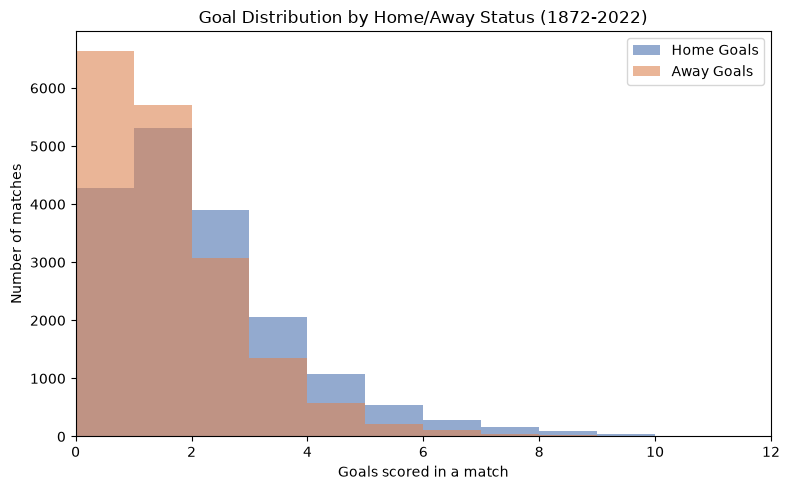

In [12]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(8, 5))
axis.hist(international_matches["Home Goals"], bins=range(0, 33), alpha=0.6, label="Home Goals", color="#4C72B0")
axis.hist(international_matches["Away Goals"], bins=range(0, 33), alpha=0.6, label="Away Goals", color="#DD8452")
axis.set_title("Goal Distribution by Home/Away Status (1872-2022)")
axis.set_xlabel("Goals scored in a match")
axis.set_ylabel("Number of matches")
axis.set_xlim(0, 12)
axis.legend()
figure.tight_layout()
plt.show()

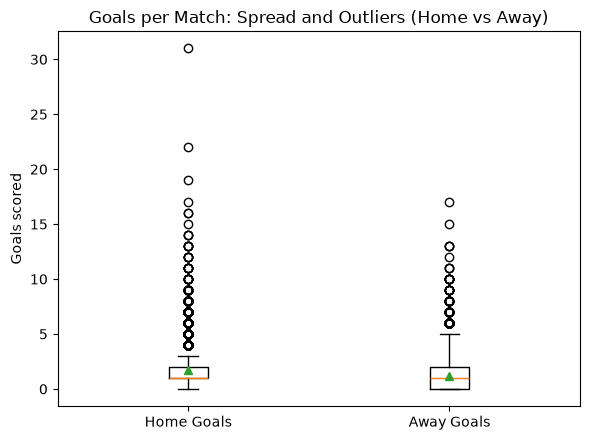

In [13]:
figure, axis = plt.subplots(figsize=(6, 4.5))
axis.boxplot(
    [international_matches["Home Goals"], international_matches["Away Goals"]],
    tick_labels=["Home Goals", "Away Goals"],
    showmeans=True
)
axis.set_title("Goals per Match: Spread and Outliers (Home vs Away)")
axis.set_ylabel("Goals scored")
figure.tight_layout()
plt.show()

Both distributions are right-skewed with a long tail of high-scoring matches, and the boxplot flags many points above the whiskers — expected for a discrete, zero-bounded scoring variable rather than a sign of corrupted data.

**Outlier detection using three methods:**

In [14]:
def find_outliers_iqr(target_series, iqr_multiplier=1.5):
    """Flag values beyond iqr_multiplier times the IQR from the first/third quartile."""
    first_quartile, third_quartile = target_series.quantile([0.25, 0.75])
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - iqr_multiplier * interquartile_range
    upper_bound = third_quartile + iqr_multiplier * interquartile_range
    return (target_series < lower_bound) | (target_series > upper_bound)


def find_outliers_zscore(target_series, zscore_threshold=3.0):
    """Flag values whose standard (mean/std based) z-score exceeds the threshold."""
    zscores = (target_series - target_series.mean()) / target_series.std()
    return zscores.abs() > zscore_threshold


def find_outliers_modified_zscore(target_series, modified_zscore_threshold=3.5):
    """Flag values whose robust (median/MAD based) modified z-score exceeds the threshold."""
    median_value = target_series.median()
    median_absolute_deviation = (target_series - median_value).abs().median()
    modified_zscores = 0.6745 * (target_series - median_value) / median_absolute_deviation
    return modified_zscores.abs() > modified_zscore_threshold


def compare_outlier_detection_methods(target_series):
    """Compare outlier counts and shares produced by three detection methods."""
    detection_methods = {
        "IQR rule": find_outliers_iqr(target_series),
        "Z-score (mean/std)": find_outliers_zscore(target_series),
        "Modified Z-score (median/MAD)": find_outliers_modified_zscore(target_series),
    }
    comparison_rows = {
        method_name: {"outlier_count": mask.sum(), "outlier_percentage": round(mask.mean() * 100, 2)}
        for method_name, mask in detection_methods.items()
    }
    return pd.DataFrame(comparison_rows).T


for goal_column in ["Home Goals", "Away Goals"]:
    print(f"--- Outlier comparison: {goal_column} ---")
    print(compare_outlier_detection_methods(international_matches[goal_column]))
    print()

--- Outlier comparison: Home Goals ---
                               outlier_count  outlier_percentage
IQR rule                              2216.0               12.47
Z-score (mean/std)                     324.0                1.82
Modified Z-score (median/MAD)          324.0                1.82

--- Outlier comparison: Away Goals ---
                               outlier_count  outlier_percentage
IQR rule                               216.0                1.22
Z-score (mean/std)                     216.0                1.22
Modified Z-score (median/MAD)          101.0                0.57



**The three methods disagree sharply, especially for Home Goals:** the IQR rule flags 12.47% of matches (2,216) as outliers, while both the Z-score and modified Z-score methods flag only ~1.8% (324). This is because Home Goals has a very tight IQR (Q1=1, Q3=2, IQR=1), so its 1.5×IQR fence sits at just 3.5 goals — anything from a 4-goal win upward gets flagged, which happens routinely in football and is not actually anomalous.

The Z-score method is itself distorted here: because it uses the mean and std, and the distribution is right-skewed, the extreme values inflate std enough to make the threshold *coincidentally* land close to the more conservative modified Z-score result for Home Goals — but for Away Goals the two diverge (216 vs 101), since Away Goals has fewer extreme values pulling its std upward.

**Practical takeaway:** for skewed, low-variance count data like goals, the IQR rule is too aggressive and the mean/std-based Z-score is itself sensitive to the outliers it is trying to detect. The median/MAD-based modified Z-score is the most defensible of the three here, since it is robust to the very extreme values it is evaluating.

### 5.2 Categorical Variables: Tournament and Team

In [15]:
def compute_category_frequency_table(target_series):
    """Return category counts, percentage share, and cumulative percentage, sorted descending."""
    category_counts = target_series.value_counts()
    category_percentage = (category_counts / len(target_series) * 100).round(2)
    return pd.DataFrame({
        "count": category_counts,
        "percentage": category_percentage,
        "cumulative_percentage": category_percentage.cumsum().round(2),
    })


def find_minimum_categories_for_coverage(frequency_table, coverage_percent):
    """Return the smallest leading set of categories whose cumulative share reaches coverage_percent."""
    covering_row_count = (frequency_table["cumulative_percentage"] < coverage_percent).sum() + 1
    return frequency_table.head(covering_row_count)


def find_rare_categories(frequency_table, rare_share_threshold):
    """Return categories whose individual share falls below rare_share_threshold percent."""
    return frequency_table[frequency_table["percentage"] < rare_share_threshold]


tournament_frequency_table = compute_category_frequency_table(international_matches["Tournament"])
tournament_frequency_table.head(10)

,count,percentage,cumulative_percentage
Tournament,,,
Friendly,7871,44.30,44.30
FIFA World Cup qualification,3541,19.93,64.23
UEFA Euro qualification,1215,6.84,71.07
Copa America,639,3.60,74.67
African Cup of Nations qualification,436,2.45,77.12
British Championship,420,2.36,79.48
African Cup of Nations,368,2.07,81.55
UEFA Euro,282,1.59,83.14
Gold Cup,250,1.41,84.55


In [16]:
print("Categories needed for 50% coverage:")
print(find_minimum_categories_for_coverage(tournament_frequency_table, 50))
print()
print("Categories needed for 80% coverage:")
print(find_minimum_categories_for_coverage(tournament_frequency_table, 80))
print()

rare_tournaments = find_rare_categories(tournament_frequency_table, rare_share_threshold=0.5)
print(f"Rare tournament categories (<0.5% share): {len(rare_tournaments)} out of "
      f"{tournament_frequency_table.shape[0]} total, covering {rare_tournaments['percentage'].sum():.2f}% of matches combined")

Categories needed for 50% coverage:
                              count  percentage  cumulative_percentage
Tournament                                                            
Friendly                       7871       44.30                  44.30
FIFA World Cup qualification   3541       19.93                  64.23

Categories needed for 80% coverage:
                                      count  percentage  cumulative_percentage
Tournament                                                                    
Friendly                               7871       44.30                  44.30
FIFA World Cup qualification           3541       19.93                  64.23
UEFA Euro qualification                1215        6.84                  71.07
Copa America                            639        3.60                  74.67
African Cup of Nations qualification    436        2.45                  77.12
British Championship                    420        2.36                  79.48
African Cup

**Most common category:** `Friendly` accounts for 44.30% of all matches — the single largest tournament type by a wide margin, followed by `FIFA World Cup qualification` at 19.93%.

**Concentration:** just 2 categories (`Friendly` + `FIFA World Cup qualification`) already cover 64.23% of matches, and only 7 categories are needed to reach 80% coverage. This despite 90 distinct tournament labels existing in total.

**Rare categories:** 72 of the 90 tournament types (80% of all categories) each account for less than 0.5% of matches, and together they cover only 7.50% of the data — one-off entries like `FIFA 75th Anniversary Cup`, `Cup of Ancient Civilizations`, and `Real Madrid 75th Anniversary Cup` appear only once or twice each. These are informative as historical curiosities (exhibition matches tied to specific commemorative events) but are not statistically useful as individual categories; for any modeling or aggregation task they should be merged into a single `Other / Exhibition` bucket rather than left as 70+ near-singleton categories.

**Team participation (Home + Away combined):**

In [17]:
# Home and Away appearances are combined so a team's overall participation is measured
# once, rather than analyzing home-side frequency alone and understating each team's true activity.
team_participation = pd.concat(
    [international_matches["Home Team"], international_matches["Away Team"]],
    ignore_index=True
)
team_frequency_table = compute_category_frequency_table(team_participation)
team_frequency_table.head(10)

,count,percentage,cumulative_percentage
England,975,2.74,2.74
Argentina,929,2.61,5.35
Brazil,907,2.55,7.90
Germany,873,2.46,10.36
South Korea,866,2.44,12.80
Mexico,864,2.43,15.23
Uruguay,860,2.42,17.65
Poland,813,2.29,19.94
Denmark,809,2.28,22.22
France,806,2.27,24.49


In [18]:
teams_for_50_percent_coverage = find_minimum_categories_for_coverage(team_frequency_table, 50)
print(f"Teams needed for 50% coverage of all appearances: {len(teams_for_50_percent_coverage)} "
      f"out of {team_frequency_table.shape[0]} total teams")

rare_teams = find_rare_categories(team_frequency_table, rare_share_threshold=0.1)
print(f"Rare teams (<0.1% share): {len(rare_teams)} teams, "
      f"covering {rare_teams['percentage'].sum():.2f}% of appearances combined")

Teams needed for 50% coverage of all appearances: 24 out of 225 total teams
Rare teams (<0.1% share): 91 teams, covering 2.79% of appearances combined


**Team participation is far more evenly spread than Tournament type:** even the most active team, England, accounts for only 2.74% of all appearances, and 24 of the 225 distinct teams are needed just to cover 50% of total appearances. Compare this to Tournament, where 2 categories alone covered 64%.

**Who dominates the log:** the top 10 are almost entirely established European and South American footballing nations (England, Argentina, Brazil, Germany, Uruguay, France) plus a few Asian/CONCACAF regulars (South Korea, Mexico). This reflects a genuine participation bias rather than a data error: nations with older, wealthier, more active federations play more international fixtures — friendlies, continental qualifiers, and tournaments — and are therefore structurally over-represented in a match-level dataset relative to smaller or newer federations. This connects directly to the cardinality finding in Section 4.4: because match count, not calendar time, drives representation, any team-level statistic computed from this table (e.g., average goals per team) will be far more reliable for the historically prolific nations than for the 91 teams appearing in fewer than 0.1% of matches each.

### Discussion: Do the central measures represent the data well?

**For the numeric variables, no — not on their own.** With skewness near 2 for both Home and Away Goals, the mean overstates the "typical" match: most games are low-scoring (median = 1 goal for both sides), but a thin tail of blowout wins (up to 31–0) drags the mean upward. The median and IQR are the more honest summary here, and the three outlier methods (Section 5.1) show that even "robust" statistics need to be chosen carefully for zero-bounded, discrete count data — the naive IQR rule alone would mislabel over 12% of ordinary matches as anomalous.

**For the categorical variables, partially.** The mode (`Friendly`) is genuinely dominant for Tournament and is a fair single-value summary, but it still leaves 55.7% of matches undescribed, and the 90-category tail means no single number can capture the full competitive landscape. For Team, no mode is meaningful at all — the maximum share is under 3%, so describing "the typical team" by its most frequent value would be actively misleading; a coverage-based view (how many teams to reach X% of appearances) is far more representative than any single central statistic.

## 6. Correlations and Relationships

### 6.1 Numeric-Numeric Correlations

Two derived numeric variables are introduced for this section: `Total Goals` (Home Goals + Away Goals) and, in the categorical analysis below, a `Match Result` category. `Total Goals` is a linear combination of the two goal columns, so its correlation with either one is partly definitional rather than a discovered relationship — this is called out explicitly below rather than presented as a finding.

Three correlation coefficients are computed for every pair, since they measure different things:
- **Pearson** measures the strength of a *linear* relationship between raw values. It is sensitive to outliers (like the 31-0 Australia match from Section 4.3) because it operates on actual magnitudes.
- **Spearman** measures the strength of a *monotonic* relationship using ranks instead of raw values. It is robust to outliers and does not assume linearity.
- **Kendall** (tau-b) also uses ranks, but compares concordance/discordance between all pairs of observations rather than a rank-difference formula. It handles tied values explicitly, which matters here since Home/Away Goals are low-cardinality integers with heavy ties (Section 5.1 showed IQR=1 for Home Goals). Kendall values are mathematically smaller in magnitude than Spearman for the same data — that is a property of the statistic, not evidence of a weaker relationship.

In [19]:
# Total Goals is engineered here for the correlation and visualization analysis below.
international_matches["Total Goals"] = international_matches["Home Goals"] + international_matches["Away Goals"]

numeric_columns_for_correlation = ["Home Goals", "Away Goals", "Total Goals", "Year"]
numeric_correlation_subset = international_matches[numeric_columns_for_correlation]

pearson_correlation_matrix = numeric_correlation_subset.corr(method="pearson")
spearman_correlation_matrix = numeric_correlation_subset.corr(method="spearman")
kendall_correlation_matrix = numeric_correlation_subset.corr(method="kendall")

print("--- Pearson ---")
print(pearson_correlation_matrix.round(3))
print("\n--- Spearman ---")
print(spearman_correlation_matrix.round(3))
print("\n--- Kendall ---")
print(kendall_correlation_matrix.round(3))

--- Pearson ---
             Home Goals  Away Goals  Total Goals   Year
Home Goals        1.000      -0.129        0.754 -0.137
Away Goals       -0.129       1.000        0.554 -0.156
Total Goals       0.754       0.554        1.000 -0.218
Year             -0.137      -0.156       -0.218  1.000

--- Spearman ---
             Home Goals  Away Goals  Total Goals   Year
Home Goals        1.000      -0.109        0.713 -0.106
Away Goals       -0.109       1.000        0.545 -0.112
Total Goals       0.713       0.545        1.000 -0.156
Year             -0.106      -0.112       -0.156  1.000

--- Kendall ---
             Home Goals  Away Goals  Total Goals   Year
Home Goals        1.000      -0.090        0.625 -0.079
Away Goals       -0.090       1.000        0.468 -0.084
Total Goals       0.625       0.468        1.000 -0.112
Year             -0.079      -0.084       -0.112  1.000


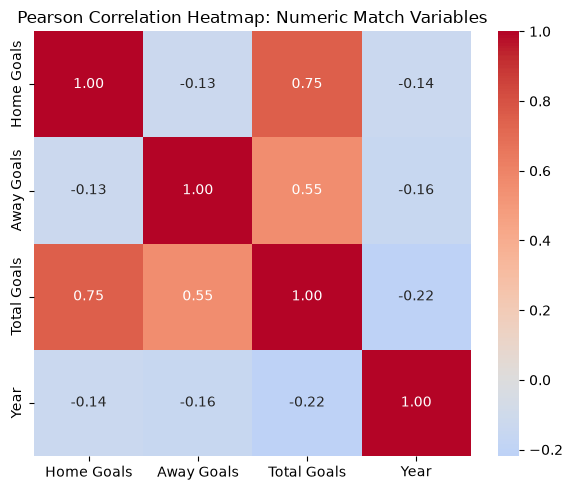

In [20]:
import seaborn as sns

figure, axis = plt.subplots(figsize=(6, 5))
sns.heatmap(pearson_correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axis)
axis.set_title("Pearson Correlation Heatmap: Numeric Match Variables")
figure.tight_layout()
plt.show()

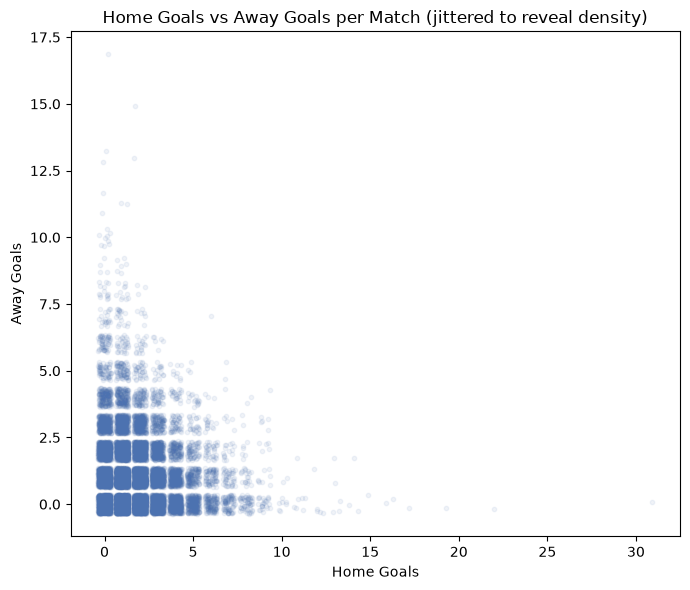

In [21]:
import numpy as np

# Home/Away Goals are low-cardinality integers, so raw points would fully overlap;
# a small random jitter reveals point density while preserving the discrete grid pattern.
random_generator = np.random.default_rng(42)
jittered_home_goals = international_matches["Home Goals"] + random_generator.uniform(-0.35, 0.35, size=len(international_matches))
jittered_away_goals = international_matches["Away Goals"] + random_generator.uniform(-0.35, 0.35, size=len(international_matches))

figure, axis = plt.subplots(figsize=(7, 6))
axis.scatter(jittered_home_goals, jittered_away_goals, alpha=0.08, s=10, color="#4C72B0")
axis.set_title("Home Goals vs Away Goals per Match (jittered to reveal density)")
axis.set_xlabel("Home Goals")
axis.set_ylabel("Away Goals")
figure.tight_layout()
plt.show()

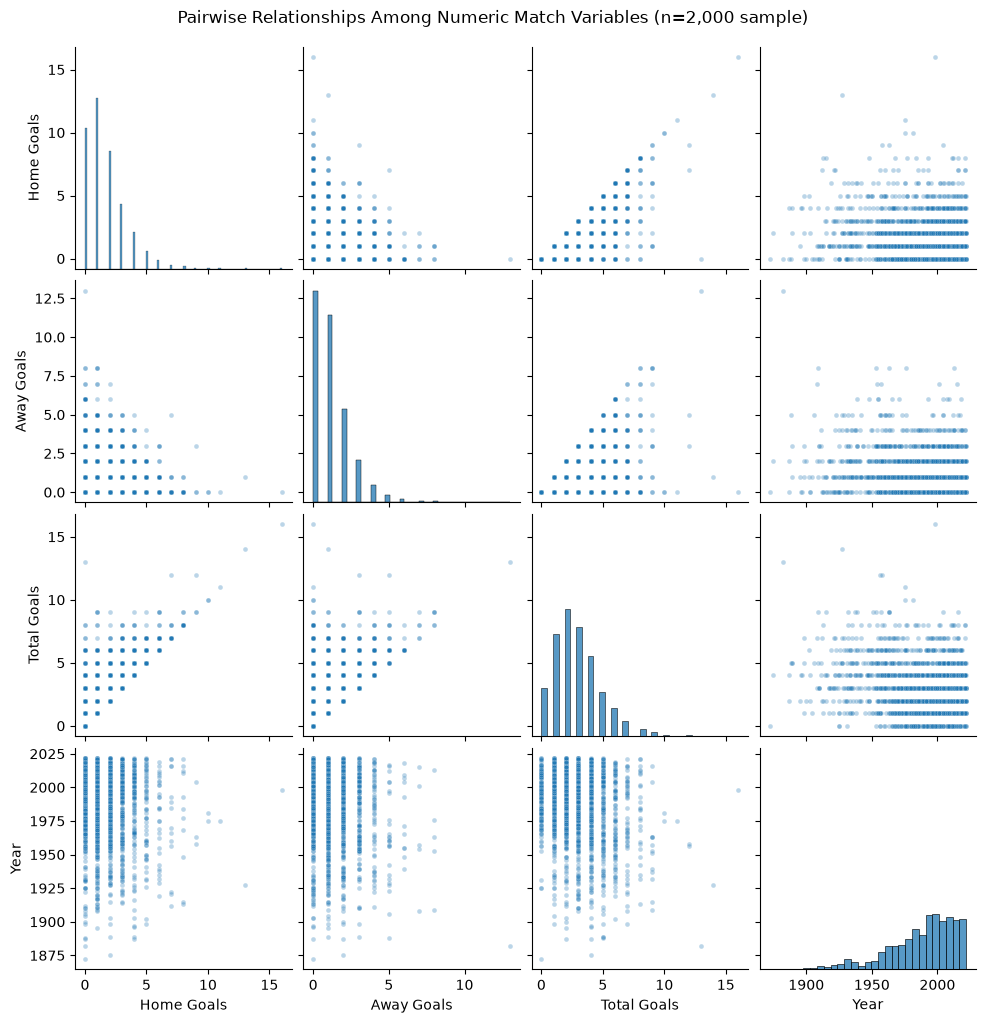

In [22]:
# A random sample keeps the pairplot readable and fast to render; the full dataset
# would produce the same discrete grid pattern, just far more overplotted.
pairplot_sample = international_matches[numeric_columns_for_correlation].sample(n=2000, random_state=42)
pairplot_grid = sns.pairplot(pairplot_sample, diag_kind="hist", plot_kws={"alpha": 0.3, "s": 12})
pairplot_grid.figure.suptitle("Pairwise Relationships Among Numeric Match Variables (n=2,000 sample)", y=1.02)
plt.show()

**Home Goals and Away Goals are weakly negatively correlated** (Pearson -0.13, Spearman -0.11, Kendall -0.09) — consistent across all three methods, all near zero but not exactly zero. This means a high-scoring performance by the home side does not typically come with a high-scoring performance by the away side, and vice versa: most matches are lopsided in one direction rather than open, high-scoring affairs for both teams. The scatterplot confirms this — the densest region hugs the low-goal corner for both axes, and the long tails run *along* each axis individually (Home Goals up to 31 with Away Goals near 0, or vice versa) rather than along the diagonal.

**Home/Away Goals vs Total Goals are moderately-to-strongly correlated by construction** (Pearson 0.75 and 0.55 respectively) — expected, since `Total Goals` is their sum, not an independently discovered relationship.

**Year is weakly negatively correlated with scoring** (Total Goals: Pearson -0.22, Spearman -0.16, Kendall -0.11). Average goals per match have declined somewhat across the 150-year span. This is a real pattern in the data, but correlation alone cannot say why — plausible explanations include genuine tactical evolution toward more organized, defensive football, or a compositional shift in which tournament types dominate each era (the earliest decades in this dataset are sparser and include more mismatched exhibition-style fixtures). Section 7 (Index Analysis) and the closing insights revisit this time trend.

**Across all three coefficients, Pearson consistently reports the largest magnitude and Kendall the smallest** for every pair — exactly the expected ordering for skewed, heavily-tied integer data, and a reminder that the *choice* of correlation method matters here, not just its sign.

### 6.2 Categorical Relationships

A `Match Result` category (Home Win / Draw / Away Win) is engineered from the two goal columns to test whether playing at the home team's own stadium (`Home Stadium or Not`) is associated with who wins — a genuinely categorical-categorical question.

In [23]:
def determine_match_result(target_dataframe):
    """Classify each match as Home Win, Away Win, or Draw from the goal columns."""
    home_result = np.select(
        [target_dataframe["Home Goals"] > target_dataframe["Away Goals"],
         target_dataframe["Home Goals"] < target_dataframe["Away Goals"]],
        ["Home Win", "Away Win"],
        default="Draw"
    )
    return home_result


international_matches["Match Result"] = determine_match_result(international_matches)
international_matches["Match Result"].value_counts()

Match Result
Home Win    8592
Away Win    5007
Draw        4170
Name: count, dtype: int64

In [24]:
from scipy.stats import chi2_contingency


def compute_cramers_v(categorical_series_a, categorical_series_b):
    """Compute Cramer's V, a chi-square-based measure of categorical association strength."""
    contingency_table = pd.crosstab(categorical_series_a, categorical_series_b)
    chi_square_statistic = chi2_contingency(contingency_table).statistic
    sample_size = contingency_table.to_numpy().sum()
    smaller_dimension = min(contingency_table.shape) - 1
    return np.sqrt(chi_square_statistic / (sample_size * smaller_dimension))


match_result_by_venue_counts = pd.crosstab(
    international_matches["Home Stadium or Not"], international_matches["Match Result"]
)
match_result_by_venue_percentage = pd.crosstab(
    international_matches["Home Stadium or Not"], international_matches["Match Result"], normalize="index"
) * 100

print("Counts:")
print(match_result_by_venue_counts)
print("\nRow percentages:")
print(match_result_by_venue_percentage.round(2))
print(f"\nCramer's V (Match Result vs Home Stadium or Not): "
      f"{compute_cramers_v(international_matches['Home Stadium or Not'], international_matches['Match Result']):.3f}")

Counts:
Match Result         Away Win  Draw  Home Win
Home Stadium or Not                          
0                        1172   849      1444
1                        3835  3321      7148

Row percentages:
Match Result         Away Win   Draw  Home Win
Home Stadium or Not                           
0                       33.82  24.50     41.67
1                       26.81  23.22     49.97

Cramer's V (Match Result vs Home Stadium or Not): 0.071


**Home advantage is real but modest by association-strength standards.** Home win rate is 49.97% when the home team plays at its own stadium, versus 41.67% at a neutral venue — an 8.3 percentage point gap that shifts primarily between "Home Win" and "Away Win" (the draw rate barely moves: 23.22% vs 24.50%). Yet Cramér's V is only 0.071, which falls in the "small/negligible" range by conventional effect-size guidelines. Both readings are correct simultaneously: the shift is large enough to matter competitively, but `Home Stadium or Not` alone explains only a small share of the overall variation in match outcomes — many other factors (team quality, tournament stakes, historical era) drive results too.

Next, `Total Goals` is binned into Low/Medium/High categories to test whether venue type is associated with how many goals get scored overall, rather than who wins:

In [25]:
international_matches["Total Goals Bin"] = pd.cut(
    international_matches["Total Goals"],
    bins=[-1, 1, 3, np.inf],
    labels=["Low (0-1)", "Medium (2-3)", "High (4+)"]
)

total_goals_bin_by_venue_percentage = pd.crosstab(
    international_matches["Home Stadium or Not"], international_matches["Total Goals Bin"], normalize="index"
) * 100

print(total_goals_bin_by_venue_percentage.round(2))
print(f"\nCramer's V (Total Goals Bin vs Home Stadium or Not): "
      f"{compute_cramers_v(international_matches['Home Stadium or Not'], international_matches['Total Goals Bin']):.3f}")

Total Goals Bin      Low (0-1)  Medium (2-3)  High (4+)
Home Stadium or Not                                    
0                        28.31         41.62      30.07
1                        25.19         41.73      33.08

Cramer's V (Total Goals Bin vs Home Stadium or Not): 0.032


**Venue has almost no association with total scoring volume** (Cramér's V = 0.032, essentially negligible): the High (4+) bin is only slightly more common at home venues (33.08%) than neutral ones (30.07%). Combined with the previous result, the picture is coherent — home advantage mainly redistributes *who* scores (shifting the balance from the away side to the home side), not *how much* scoring happens overall.

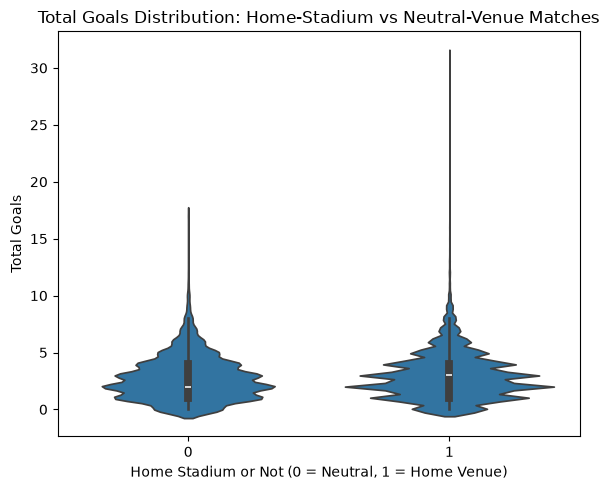

In [26]:
figure, axis = plt.subplots(figsize=(6, 5))
sns.violinplot(data=international_matches, x="Home Stadium or Not", y="Total Goals", ax=axis)
axis.set_title("Total Goals Distribution: Home-Stadium vs Neutral-Venue Matches")
axis.set_xlabel("Home Stadium or Not (0 = Neutral, 1 = Home Venue)")
axis.set_ylabel("Total Goals")
figure.tight_layout()
plt.show()

The violin plot visually confirms the near-identical total-goals distributions across venue types — both are right-skewed with a similar median and spread, reinforcing the negligible Cramér's V above.

The remaining mandatory chart types (bar chart and pie chart) close out this section, both revisiting the Tournament frequency findings from Section 5.2 in visual form:

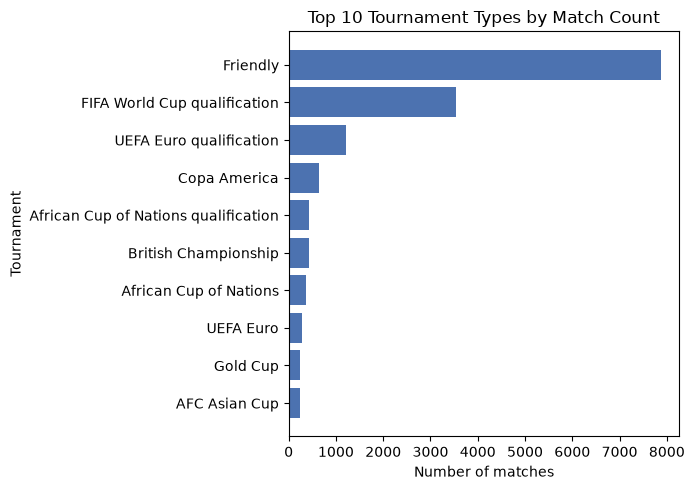

In [27]:
top_ten_tournaments = international_matches["Tournament"].value_counts().head(10)

figure, axis = plt.subplots(figsize=(7, 5))
axis.barh(top_ten_tournaments.index[::-1], top_ten_tournaments.values[::-1], color="#4C72B0")
axis.set_title("Top 10 Tournament Types by Match Count")
axis.set_xlabel("Number of matches")
axis.set_ylabel("Tournament")
figure.tight_layout()
plt.show()

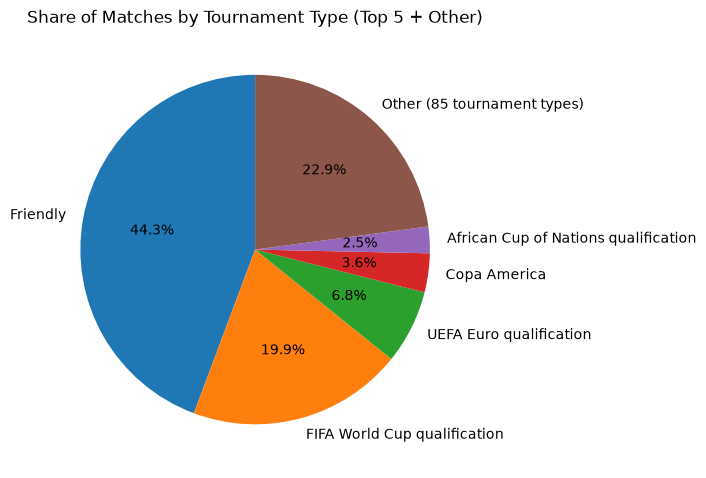

In [28]:
tournament_frequency = international_matches["Tournament"].value_counts()
top_five_tournaments = tournament_frequency.head(5)
remaining_tournaments_share = tournament_frequency.iloc[5:].sum()
tournament_pie_data = pd.concat([
    top_five_tournaments,
    pd.Series({"Other (85 tournament types)": remaining_tournaments_share})
])

figure, axis = plt.subplots(figsize=(7, 7))
axis.pie(tournament_pie_data.values, labels=tournament_pie_data.index, autopct="%1.1f%%", startangle=90)
axis.set_title("Share of Matches by Tournament Type (Top 5 + Other)")
figure.tight_layout()
plt.show()

### Section Summary: What the Correlations Tell Us

Three conclusions carry forward from this section: (1) football scoring is lopsided rather than jointly high or low for both sides (the weak negative Home/Away Goals correlation), (2) match outcomes have a real but modest dependency on venue — Cramér's V of 0.07 for who wins versus 0.03 for how much is scored — showing that home advantage is a *result* effect more than a *scoring-volume* effect, and (3) the negative Year–Total Goals correlation flags a time trend worth deeper investigation in a future time-dependency analysis, since correlation alone cannot separate genuine tactical change from a shifting mix of tournament types across eras.

## 7. Index Analysis

This section examines three candidate row identifiers — the default pandas `RangeIndex`, the `ID` column, and the `Date` column — for uniqueness, time-dependence, and sort order, then tests whether the statistical patterns found in earlier sections actually hold steady across the dataset's 150-year time span.

### 7.1 The Working Index (Default RangeIndex)

In [29]:
print(f"Index type: {type(international_matches.index).__name__}")
print(f"Is unique: {international_matches.index.is_unique}")
print(f"Is monotonic increasing: {international_matches.index.is_monotonic_increasing}")

Index type: RangeIndex
Is unique: True
Is monotonic increasing: True


The default `RangeIndex` is trivially unique and sorted (0 to 17,768, ascending by construction), but it is not time-based in any meaningful sense — it is simply the row's position after loading the CSV, with no independent semantic content. It happens to align with chronological order only because the underlying file itself was already sorted by date (confirmed in Section 7.3). Two better candidates exist in the data itself: `ID` and `Date`.

### 7.2 `ID` as a Candidate Index

In [30]:
is_id_sequential = (international_matches["ID"] == np.arange(1, len(international_matches) + 1)).all()

# If sorting by ID ever moves a later date before an earlier one, chronological order is broken.
date_when_sorted_by_id = pd.to_datetime(international_matches.sort_values("ID")["Date"])
backward_date_steps = (date_when_sorted_by_id.diff().dt.days < 0).sum()

print(f"ID is unique: {international_matches['ID'].is_unique}")
print(f"ID is monotonic increasing: {international_matches['ID'].is_monotonic_increasing}")
print(f"ID is an exact 1..n sequence: {is_id_sequential}")
print(f"Backward date steps when sorted by ID: {backward_date_steps} out of {len(international_matches) - 1}")

ID is unique: True
ID is monotonic increasing: True
ID is an exact 1..n sequence: True
Backward date steps when sorted by ID: 0 out of 17768


**`ID` is unique** (confirmed already in Section 4.4) **and forms an exact 1-to-17,769 sequence** — a clean surrogate key with no gaps or reuse. More interestingly, **`ID` is implicitly time-based**: sorting by `ID` never produces a backward step in `Date` (0 out of 17,768 transitions), meaning the dataset's compilers assigned IDs in strict chronological order of when each match was played. `ID` is therefore both a valid unique index and a reliable proxy for match chronology, even though it carries no date information on its face.

### 7.3 `Date` as a Candidate Index

In [31]:
parsed_dates = pd.to_datetime(international_matches["Date"])
matches_per_date = international_matches["Date"].value_counts()

print(f"Date is unique: {international_matches['Date'].is_unique} "
      f"({international_matches['Date'].nunique()} distinct dates for {len(international_matches)} matches)")
print(f"Date is monotonic increasing (raw file order): {parsed_dates.is_monotonic_increasing}")
print(f"Most matches recorded on a single date: {matches_per_date.max()} (on {matches_per_date.idxmax()})")

Date is unique: False (9004 distinct dates for 17769 matches)
Date is monotonic increasing (raw file order): True
Most matches recorded on a single date: 27 (on 2009-08-12)


**`Date` is explicitly time-based but not unique** — only 9,004 distinct dates cover 17,769 matches, and as many as 27 separate fixtures share a single date (2009-08-12), since many qualifiers and continental tournaments schedule matches worldwide on the same day. `Date` alone therefore cannot serve as a primary key; this is exactly why Section 4.2's duplicate check used the composite key (`Date`, `Home Team`, `Away Team`) rather than `Date` in isolation.

**The data is already sorted ascending by `Date`** in its raw file order (confirmed monotonic), which is also why the default `RangeIndex` and `ID` both happen to track chronology — all three orderings agree.

### 7.4 Does the Earlier Analysis Change Over Time?

Section 6.1 found a weak negative correlation between `Year` and `Total Goals` but could not distinguish genuine tactical change from a shifting mix of tournament types across eras. Since `Date`/`ID` confirm the data is a genuine, orderable time series, that question can now be tested directly: split the matches into four historical eras and recompute the key numeric statistics from Sections 5 and 6 within each one.

In [32]:
era_bin_edges = [1871, 1949, 1979, 1999, 2023]
era_labels = ["Pre-1950", "1950-1979", "1980-1999", "2000-2022"]
international_matches["Era"] = pd.cut(international_matches["Year"], bins=era_bin_edges, labels=era_labels)


def summarize_era(era_group):
    """Recompute key numeric statistics (mean, skewness, correlation, outlier share) within one era."""
    total_goals = era_group["Total Goals"]
    median_total_goals = total_goals.median()
    median_absolute_deviation = (total_goals - median_total_goals).abs().median()
    modified_zscores = 0.6745 * (total_goals - median_total_goals) / median_absolute_deviation
    return pd.Series({
        "match_count": len(era_group),
        "mean_total_goals": total_goals.mean(),
        "median_total_goals": median_total_goals,
        "skewness_total_goals": total_goals.skew(),
        "home_away_goal_correlation": era_group["Home Goals"].corr(era_group["Away Goals"]),
        "outlier_percentage": (modified_zscores.abs() > 3.5).mean() * 100,
    })


era_summary_table = international_matches.groupby("Era", observed=True).apply(
    summarize_era, include_groups=False
)
era_summary_table.round(3)

,match_count,mean_total_goals,median_total_goals,skewness_total_goals,home_away_goal_correlation,outlier_percentage
Era,,,,,,
Pre-1950,1810.0,4.182,4.0,0.799,-0.194,0.110
1950-1979,3751.0,3.159,3.0,0.894,-0.115,1.786
1980-1999,4826.0,2.521,2.0,1.127,-0.136,1.575
2000-2022,7382.0,2.681,2.0,1.598,-0.186,1.422


**Yes — the earlier analysis changes substantially across eras, and not always in the direction one number would suggest:**

- **Average scoring genuinely declined and then partly recovered:** mean Total Goals falls steadily from 4.18 (Pre-1950) to 3.16 (1950-1979) to 2.52 (1980-1999), then ticks back up slightly to 2.68 (2000-2022). A single dataset-wide Pearson correlation (-0.22, Section 6.1) compresses this into one straight-line trend and completely hides the recent partial recovery.
- **Skewness roughly doubles over time** (0.80 → 0.89 → 1.13 → 1.60): modern matches cluster much more tightly around a low, defensive-era score, making the occasional high-scoring game relatively more extreme than a similar scoreline would have been in the wide-open, high-scoring football of the pre-1950 era.
- **The weak negative Home/Away Goals correlation from Section 6.1 (-0.13 overall) is stable across every era** (ranging narrowly from -0.11 to -0.19), so that particular finding is not an artifact of any single period — lopsided rather than jointly high-scoring matches have been the norm throughout the dataset's 150-year span.
- **The outlier-detection rate itself is not stationary:** the modified Z-score method flags only 0.11% of Pre-1950 matches but 1.4-1.8% of matches from every era since. This is a direct consequence of the skewness shift above — Pre-1950 scores were naturally more spread out, so their own median absolute deviation was wide enough that even a 9-0 result didn't register as statistically extreme within that era's baseline. Applying one dataset-wide outlier threshold (as Section 5.1 did) implicitly measures every match against the tighter, modern distribution, which is worth flagging as a limitation of that earlier analysis rather than treating it as a settled result.

**Takeaway for the index:** because `ID`/`Date` establish a trustworthy chronological order, this kind of era-sliced re-analysis is possible at all — it would not be meaningful on a dataset with an arbitrary or shuffled index. Any statistic computed once over the full 150-year range should be treated as an average-of-averages rather than a stable property of "international football," and re-examined by era whenever the underlying phenomenon is plausibly non-stationary.

## 8. Insights and Data Story

### Key Insights

1. **Home advantage shifts who wins, not how much gets scored.** Playing at the home team's own stadium raises the home win rate from 41.67% to 49.97% (Section 6.2), but Cramér's V for venue vs. match result is only 0.071, and venue vs. total-goals volume is a negligible 0.032. The effect is real and directionally consistent, but it is a redistribution of outcomes between the two sides rather than a change in overall scoring intensity — a more precise claim than the blanket notion of "home advantage" usually implies.

2. **International football has become lower-scoring and more skewed, with a partial modern rebound.** Mean Total Goals per match fell from 4.18 (Pre-1950) to 2.52 (1980-1999), then rose slightly to 2.68 (2000-2022), while skewness roughly doubled over the same span (0.80 → 1.60, Section 7.4). The single dataset-wide correlation computed in Section 6.1 (Year vs. Total Goals, Pearson -0.22) is real but too coarse to see this — it reads as one steady decline and hides the recent partial recovery entirely.

3. **The World Cup enrichment join has a hidden, non-obvious gap.** 82.05% missingness in the eight `world_cups`-derived columns is mostly structural and expected (Section 4.1), but `world_cups1.csv` silently stops at 2018 — so the 236 matches from the 2022 tournament year are indistinguishable from a genuine non-World-Cup year. This was only detectable by cross-checking the join key against known football history, not from the missingness count alone.

4. **Dataset representation is concentrated in established, historically active football nations.** Just 24 of 225 teams account for half of all match appearances, and the most active team (England) still accounts for only 2.74% (Section 5.2). Wealthier, longer-established federations play more fixtures and are structurally over-represented — any team-level statistic drawn from this table will be far more reliable for those nations than for the 91 teams appearing in under 0.1% of matches each.

5. **Outlier detection is method-sensitive and era-sensitive at the same time.** The naive IQR rule flags 12.47% of Home Goals values as outliers versus ~1.8% for the more defensible Z-score/modified-Z-score methods (Section 5.1) — and even the robust modified-Z-score method's flag rate shifts from 0.11% (Pre-1950) to ~1.4-1.8% (every era since), because the scoring distribution itself has narrowed over time (Section 7.4). There is no single "correct" outlier threshold for a 150-year, non-stationary sports series.

### Bias and Risk

- **Participation bias / survivorship of well-resourced federations.** Because representation in this dataset is driven by how many fixtures a federation could historically arrange (Section 5.2), the data reflects "which nations played the most international football" as much as it reflects the sport itself. Conclusions about "typical" match outcomes are implicitly conclusions about historically wealthy, well-connected footballing nations, not a neutral global sample.
- **Historical-entity fragmentation.** Defunct national teams — West Germany, East Germany, Yugoslavia, Zaire — appear as categories distinct from their modern successor states (Section 4.4). Any longitudinal "by country" analysis that does not explicitly reconcile these lineages will systematically undercount a nation's true match history and misattribute historical performance.
- **Silent reference-table staleness.** The 2022 gap in `world_cups1.csv` (Key Insight 3 above, Section 4.1) is the clearest concrete risk in this notebook: a secondary/joined data source can degrade data quality in ways that are completely invisible from standard missing-value counts, and only surface through domain knowledge cross-checks.

### Potential Failure Points for Engineering and Statistical Use

- **Silent join leakage.** A pipeline that treats the merged `international_matches_enriched` World Cup columns as "the outcome of this match" would be wrong for 82.05% of rows, since those columns are tournament-level constants broadcast across every match played that year (Section 4.1), not match-specific features.
- **Naive automated outlier alerting.** A monitoring system using the plain IQR rule on raw goal counts would flag roughly 1 in 8 ordinary matches as anomalous (Section 5.1) — enough false positives to make any human-reviewed alert queue useless in practice.
- **Stationarity assumptions in anomaly detection or forecasting.** Any model computing a single historical baseline "expected goals" or outlier threshold over the full 150-year range will misjudge modern matches, since the underlying scoring distribution has measurably shifted (Section 7.4). This is a direct violation of the stationarity assumption that many standard statistical control-chart and z-score methods rely on.
- **Team-level aggregation without small-sample correction or name reconciliation.** Rankings or per-team averages computed naively will be dominated by noise for the 91 teams with under 0.1% of appearances each (small effective sample sizes), and will silently fragment single nations' histories across renamed or dissolved entities unless that mapping is built first.
- **Treating `Date` as a unique key.** `Date` alone covers only 9,004 distinct values for 17,769 matches, with up to 27 matches sharing a single day (Section 7.3). Any downstream process that joins or deduplicates on `Date` alone (rather than `ID`, or the composite `Date` + `Home Team` + `Away Team` key used in Section 4.2) will silently drop or merge unrelated matches.

### What I Learned, and Where My Thinking Changed

Going in, the two failure modes I expected to dominate this dataset were missing values and duplicate rows — the standard checklist items. In practice, the raw match log was remarkably clean at the row level: zero full or fixture-level duplicates, no impossible values, and no missingness at all outside the enrichment columns. The real data-quality risk turned out to be one level higher, in the *design of the join* itself — a reference table that silently stopped three years short of the data it was merged into. That is a harder failure mode to catch than a `NaN` count, and it changed how I now think about "data quality": it is not just a property of a single table, but of every join and assumption layered on top of it.

I also expected "home advantage" to be a dominant, headline-scale effect; measuring it with Cramér's V rather than just comparing raw win rates showed it is real but modest in association-strength terms, which was a useful correction against overstating a single intuitive factor in sports analytics. Finally, running the same statistics (skewness, correlation, outlier rate) by era rather than once over the full range was the single most informative change in approach in this notebook — several "settled" findings from Sections 5 and 6 turned out to be an average of quite different underlying regimes once the 150-year span was actually respected as a time series rather than one static sample.

## 9. Bonus

### A Formal Hypothesis Test: Does the Home Stadium Increase the Home Win Rate?

Section 6.2 found a small Cramer's V (0.071) between `Home Stadium or Not` and `Match Result`, alongside an 8.3 percentage point gap in raw home win rates (49.97% vs. 41.67%). A formal hypothesis test resolves the tension between "small effect size" and "large practical gap":

- **H0 (null hypothesis):** `Match Result` is independent of `Home Stadium or Not` -- home advantage has no effect on match outcome.
- **H1 (alternative hypothesis):** `Match Result` is associated with `Home Stadium or Not`.
- **Test:** a chi-square test of independence on the same contingency table computed in Section 6.2, at a significance level of alpha = 0.05.

In [33]:
chi_square_statistic, p_value, degrees_of_freedom, _ = chi2_contingency(match_result_by_venue_counts)

print(f"Chi-square statistic: {chi_square_statistic:.2f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"p-value: {p_value:.3e}")
print(f"Reject H0 at alpha=0.05: {p_value < 0.05}")

Chi-square statistic: 90.37
Degrees of freedom: 2
p-value: 2.376e-20
Reject H0 at alpha=0.05: True


**H0 is rejected decisively** (chi-square = 90.37, p ~ 2.4e-20, far below alpha = 0.05). With a sample this large (n = 17,769), even a modest association between venue and outcome is picked up as statistically significant with overwhelming confidence.

**This is precisely why effect size and statistical significance answer different questions.** The p-value confirms the home-advantage association is real and did not arise by chance; the small Cramer's V from Section 6.2 confirms it is not a large driver of outcomes relative to everything else that determines who wins a football match (team quality, tournament stakes, historical era, and more). Reporting only the p-value here would overstate how much venue matters; reporting only Cramer's V would understate how confident we can be that the effect exists at all. Both numbers are needed to tell an honest story.

### Engineering Feature: External Time-Context (Rule Eras)

Football's rules changed several times across this dataset's 150-year span. A categorical `Rule Era` feature is engineered from three well-documented external events -- not present in the data itself -- to connect the Section 7.4 scoring-decline finding to real candidate causes rather than leaving it as an unexplained correlation with `Year`:

- **Pre-1970**: before yellow/red cards existed (introduced at the 1970 World Cup).
- **1970-1991**: cards era, before the back-pass law.
- **1992-2017**: back-pass law in effect (goalkeepers could no longer pick up deliberate back-passes), before VAR.
- **2018-2022**: VAR (Video Assistant Referee) era, introduced at the 2018 World Cup.

In [34]:
rule_era_bin_edges = [1871, 1969, 1991, 2017, 2023]
rule_era_labels = [
    "Pre-1970 (before cards)",
    "1970-1991 (cards, pre-back-pass law)",
    "1992-2017 (back-pass law, pre-VAR)",
    "2018-2022 (VAR era)",
]
international_matches["Rule Era"] = pd.cut(
    international_matches["Year"], bins=rule_era_bin_edges, labels=rule_era_labels
)

international_matches.groupby("Rule Era", observed=True)["Total Goals"].agg(
    match_count="count", mean_total_goals="mean", median_total_goals="median", std_total_goals="std"
).round(3)

,match_count,mean_total_goals,median_total_goals,std_total_goals
Rule Era,,,,
Pre-1970 (before cards),3898,3.837,4.0,2.318
"1970-1991 (cards, pre-back-pass law)",4196,2.513,2.0,1.743
"1992-2017 (back-pass law, pre-VAR)",8271,2.671,2.0,1.878
2018-2022 (VAR era),1404,2.696,2.0,1.861


**The steepest scoring drop lines up with the 1970 cards introduction**, not with the back-pass law or VAR: mean Total Goals falls from 3.84 (Pre-1970) to 2.51 (1970-1991) -- a much larger jump than any later transition (2.51 to 2.67 to 2.70 across the two subsequent rule eras, both essentially flat). This is a genuinely different cut of the same time trend already found in Section 7.4 (which used arbitrary 20/30-year bins), and it narrows the plausible explanation: whatever drove the historical scoring decline, it happened earlier and faster than the back-pass law or VAR could have caused, and roughly coincides with football professionalizing and organizing more tightly around the 1970s rather than any single rule change captured here.

**This remains correlational, not causal** -- exactly the caveat Section 7.4 raised. `Rule Era` is still built purely from `Year`, so it cannot separate "the rules changed" from "everything else about the sport also changed at the same time" (better global TV coverage, more competitive balance, more federations playing). It does, however, connect the dataset's internal time trend to real, externally documented history rather than leaving `Year` as an unexplained numeric axis, and it is a concrete example of engineering a feature from outside knowledge rather than from the columns already present in the raw files.

### Additional Hypotheses Worth Testing

These are proposed but not executed here, as natural extensions of findings already surfaced in the notebook:

- **Does mean `Total Goals` differ across the four historical eras from Section 7.4?** A Kruskal-Wallis test (the non-parametric analogue of one-way ANOVA, appropriate given the right-skewed, non-normal goal distributions from Section 5.1) could formally confirm whether the Pre-1950 vs. modern-era scoring gap is statistically significant, not just descriptively large.
- **Do Home Goals and Away Goals come from different distributions?** A paired Wilcoxon signed-rank test (robust to the skew noted in Section 5.1) could formally test whether the home-scoring edge visible in the Section 5.1 summary statistics (mean 1.72 vs. 1.17) is statistically significant match-by-match, rather than only in aggregate.
- **Is scoring level associated with tournament seriousness?** A test comparing `Total Goals` between `Friendly` matches and competitive fixtures (e.g. `FIFA World Cup qualification`) could quantify whether stakes measurably suppress or inflate scoring -- a natural extension of the Section 6.2 categorical analysis.

### Suggestions for Further Research

- **Reconcile historical national entities.** Mapping West Germany -> Germany, Yugoslavia -> its successor states, and similar cases (Section 4.4) would allow accurate long-run, per-nation trend analysis instead of artificially fragmented histories.
- **Close the 2022 reference-table gap.** Backfilling `world_cups1.csv` using the already-available `world_cup_matches1.csv` / `2022_world_cup_matches1.csv` files (flagged in Section 4.1) would remove the one genuine data-quality gap identified in this notebook.
- **Disentangle tactical change from compositional shift.** The declining-then-rebounding scoring trend in Section 7.4 could be re-tested on a single, consistent tournament type (e.g. `Friendly` matches only) across all four eras, to check whether the trend survives once the changing mix of tournament types over time is controlled for.
- **Formally test the `Rule Era` differences.** The Engineering Feature subsection above shows the steepest scoring drop coincides with the 1970 cards introduction, but that reading is purely descriptive (group means). A Kruskal-Wallis test across the four `Rule Era` groups would confirm whether that drop is statistically significant, paralleling the era test already proposed for Section 7.4. It would also be worth adding World Cup field expansions (16 to 24 to 32 teams) as a second, independent external time marker not yet incorporated into `Rule Era`.
- **Incorporate FIFA ranking data.** A ranking-differential feature (using an external FIFA world ranking dataset) merged onto each match could test whether the pre-match ranking gap between two teams predicts goal difference more strongly than the weak associations found for `Home Stadium or Not` alone.